# 5 · Composite laminates

Classical Lamination Theory: ABD matrices, ply stresses, and failure. Theory:
[docs/composite_laminates.md](../docs/composite_laminates.md).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from structures import plotting as P

P.use_style()
DEG = np.pi / 180
MPA = 1e6
from structures.composite_laminates import Laminate, reduced_stiffness
from structures.materials import ply

In [2]:
ge = ply("T300/5208")
print("Q [GPa] =\n", np.round(reduced_stiffness(ge) / 1e9, 3))
lam = Laminate.from_angles(ge, [0, 90, 0], 0.005)   # Kaw's [0/90/0] example, 5 mm plies
A, B, D = lam.stiffness()
print("A [Pa m] =\n", A.round(-4)); print("max |B| =", np.abs(B).max())
c = lam.engineering_constants()
print(f"Ex = {c['Ex']/1e9:.1f} GPa, Ey = {c['Ey']/1e9:.2f} GPa, nuxy = {c['nuxy']:.5f}")

Q [GPa] =
 [[181.811   2.897   0.   ]
 [  2.897  10.346   0.   ]
 [  0.      0.      7.17 ]]
A [Pa m] =
 [[1.86984e+09 4.34500e+07 0.00000e+00]
 [4.34500e+07 1.01252e+09 0.00000e+00]
 [0.00000e+00 0.00000e+00 1.07550e+08]]
max |B| = 9.313225746154785e-10
Ex = 124.5 GPa, Ey = 67.43 GPa, nuxy = 0.04292


In [3]:
for pt in lam.ply_points(N=(1, 0, 0)):
    if pt.position == "middle":
        print(f"ply {pt.ply} ({round(lam.plies[pt.ply].angle/DEG)} deg): sigma_12 = {pt.stress_12.round(3)} Pa per N/m")
for load, failed in lam.ply_by_ply_failure(N=(1, 0, 0)):
    print(f"Nx = {load:.4e} N/m: plies {failed} fail")

ply 0 (0 deg): sigma_12 = [97.264  1.313  0.   ] Pa per N/m
ply 1 (90 deg): sigma_12 = [-2.626  5.472 -0.   ] Pa per N/m
ply 2 (0 deg): sigma_12 = [97.264  1.313  0.   ] Pa per N/m
Nx = 7.2766e+06 N/m: plies [1] fail
Nx = 1.5000e+07 N/m: plies [0, 2] fail


The 90° ply cracks first, at Nx = 7.28 MN/m. The 0° plies then carry everything until fibre failure at 15 MN/m, as in Kaw's ply-by-ply example.

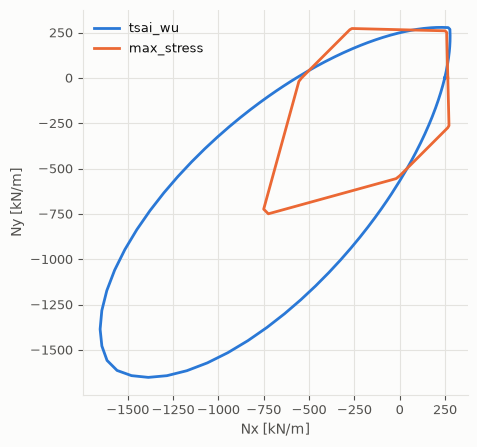

In [4]:
ht = ply("T300/976")
t = 0.0053 * 0.0254
qi = Laminate.from_angles(ht, [0, 45, -45, 90], t, symmetric=True)
phi = np.linspace(0, 2 * np.pi, 181)
fig, ax = plt.subplots(figsize=(5, 5))
for k, crit in enumerate(["tsai_wu", "max_stress"]):
    r = np.array([qi.first_ply_failure(N=(np.cos(p), np.sin(p), 0), criterion=crit)[0] for p in phi])
    ax.plot(r * np.cos(phi) / 1e3, r * np.sin(phi) / 1e3, label=crit, color=P.SERIES[k])
ax.set_aspect("equal"); ax.set_xlabel("Nx [kN/m]"); ax.set_ylabel("Ny [kN/m]"); ax.legend();